In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# -----------------------------------------------------
# PATHS
# -----------------------------------------------------

BASE_DIR = Path.cwd()
while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

STEP1_PATH = BASE_DIR / "outputs" / "step1"
PROCESSED_PATH = BASE_DIR / "data" / "processed"

df_rsv = pd.read_excel(STEP1_PATH / "rsv_lombardia.xlsx")
df_it = pd.read_csv(PROCESSED_PATH / "italy_dataset.csv")
df_us = pd.read_csv(PROCESSED_PATH / "usa_complete_dataset.csv")

In [ ]:
# -----------------------------------------------------
# ANNUAL GROWTH
# -----------------------------------------------------

vax_it = df_it[
    (df_it["region"] == "Italy") &
    (df_it["age_class"] == "65+")
].copy()

vax_it["vaccination_ratio"] = pd.to_numeric(
    vax_it["vaccination_ratio_influenza"],
    errors="coerce"
)

vax_it = vax_it.dropna(subset=["vaccination_ratio"])

vax_cov_season = (
    vax_it.groupby("flu_season")["vaccination_ratio"]
    .mean()
    .reset_index()
)

vax_cov_season["year"] = (
    vax_cov_season["flu_season"].str[:4].astype(int)
)

vax_cov_season = vax_cov_season.sort_values("year")

annual_growth = (
    vax_cov_season["vaccination_ratio"]
    .diff()
    .median()
)

print("Estimated annual uptake growth:", annual_growth)


# -----------------------------------------------------
# PLATEAU SCENARIOS
# -----------------------------------------------------

recent_mean = (
    vax_cov_season["vaccination_ratio"]
    .head(5)
    .mean()
)

plateau_scenarios = {
    "low":  {
        "plateau": (recent_mean * 0.8) / 100,
        "growth": annual_growth * 1
    },
    "mid":  {
        "plateau": (recent_mean) / 100,
        "growth": annual_growth * 1.5
    },
    "high": {
        "plateau": (recent_mean * 1.4) / 100,
        "growth": annual_growth * 1.75
    }
}

initial_cov = 0.2
INITIAL_SEASON_COVERAGE = 0.1

# -----------------------------------------------------
# WEEKLY TEMPLATE
# -----------------------------------------------------

usa_vax = df_us.copy()

usa_vax["Vaccination Rate"] = pd.to_numeric(
    usa_vax["Vaccination Rate"], errors="coerce"
)

usa_vax = usa_vax.dropna(subset=["Vaccination Rate"])

usa_vax = usa_vax.sort_values(
    ["flu_season", "HHS region", "week"]
)

usa_vax["cum_vax"] = (
    usa_vax.groupby(["HHS region", "flu_season"])
    ["Vaccination Rate"]
    .cummax()
)

usa_vax["season_week"] = np.where(
    usa_vax["week"] >= 40,
    usa_vax["week"] - 39,
    usa_vax["week"] + 13
)

weekly_shape = (
    usa_vax.groupby("season_week")["cum_vax"]
    .mean()
    .reset_index()
)

EARLY_SHIFT_STRENGTH = 2.5

weekly_shape = weekly_shape.sort_values("season_week")

max_week = weekly_shape["season_week"].max()

weekly_shape["early_weight"] = (
    1 - (weekly_shape["season_week"] - 1) / max_week
) ** EARLY_SHIFT_STRENGTH

weekly_shape["weighted_curve"] = (
    weekly_shape["cum_vax"] *
    weekly_shape["early_weight"]
)

weekly_shape["template_shape"] = (
    weekly_shape["weighted_curve"] /
    weekly_shape["weighted_curve"].sum()
)

template_df = weekly_shape[["season_week", "template_shape"]].copy()

print(template_df.head())
# -----------------------------------------------------
# LOGISTIC FUNCTIONS
# -----------------------------------------------------

def logistic_adoption(future_seasons, plateau, initial_cov, growth):

    r = max(growth, 0.01)
    
    cov = initial_cov
    coverage = []

    for _ in future_seasons:
        cov = cov + r * cov * (1 - cov / plateau)
        cov = min(cov, plateau)
        coverage.append(cov)

    return coverage


# -----------------------------------------------------
# SCENARIOS APPLICATION
# -----------------------------------------------------

future["season_week"] = np.where(
    future["week"] >= 40,
    future["week"] - 39,
    future["week"] + 13
)

future["season_week"] = np.where(
    future["week"] >= 40,
    future["week"] - 39,
    future["week"] + 13
)

all_scenarios = []

future = future.drop(
    columns=[
        c for c in future.columns
        if c.startswith("season_cov")
        or c.startswith("template_shape")
        or c.startswith("vax_")
    ],
    errors="ignore"
)
for scen_name, params in plateau_scenarios.items():
    
    plateau = params["plateau"]
    growth  = params["growth"]
    
    coverage = logistic_adoption(
        future_seasons,
        plateau,
        initial_cov,
        growth
    )
    
    cov_df = pd.DataFrame({
        "flu_season": future_seasons,
        "season_cov": coverage
    })
    
    future_scen = future.copy()
    
    future_scen = future_scen.merge(
        cov_df,
        on="flu_season",
        how="left"
    )
    
    future_scen = future_scen.merge(
        template_df,
        on="season_week",
        how="left"
    )
    
    future_scen["vax_weekly"] = (
        future_scen["template_shape"]
        * future_scen["season_cov"]
    )
    
    future_scen = future_scen.sort_values(
        ["flu_season", "season_week"]
    )
    
    future_scen["vax_cov"] = (
        future_scen.groupby("flu_season")["vax_weekly"]
        .cumsum()
        + INITIAL_SEASON_COVERAGE
    )
    
    future_scen["vax_cov"] = np.minimum(
        future_scen["vax_cov"],
        future_scen["season_cov"]
    )
    
    future_scen["vax_weekly_lag2"] = (
        future_scen.groupby("flu_season")["vax_weekly"]
        .shift(2)
        .fillna(0)
    )
    
    future_scen["vax_cov_lag2"] = (
        future_scen.groupby("flu_season")
        ["vax_weekly_lag2"]
        .cumsum()
    )
    
    future_scen["scenario"] = scen_name
    
    all_scenarios.append(future_scen)

future_all = pd.concat(all_scenarios, ignore_index=True)

OUTPUT_PATH = BASE_DIR / "outputs" / "step2"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

future_all.to_csv(
    OUTPUT_PATH / "future_scenarios.csv",
    index=False
)

print("Vaccination scenarios saved.")

Estimated annual uptake growth: 0.5500000000000007
   season_week  template_shape
0            1        0.088127
1            2        0.068682
2            3        0.065365
3            4        0.062145
4            5        0.059023
Vaccination scenarios saved.


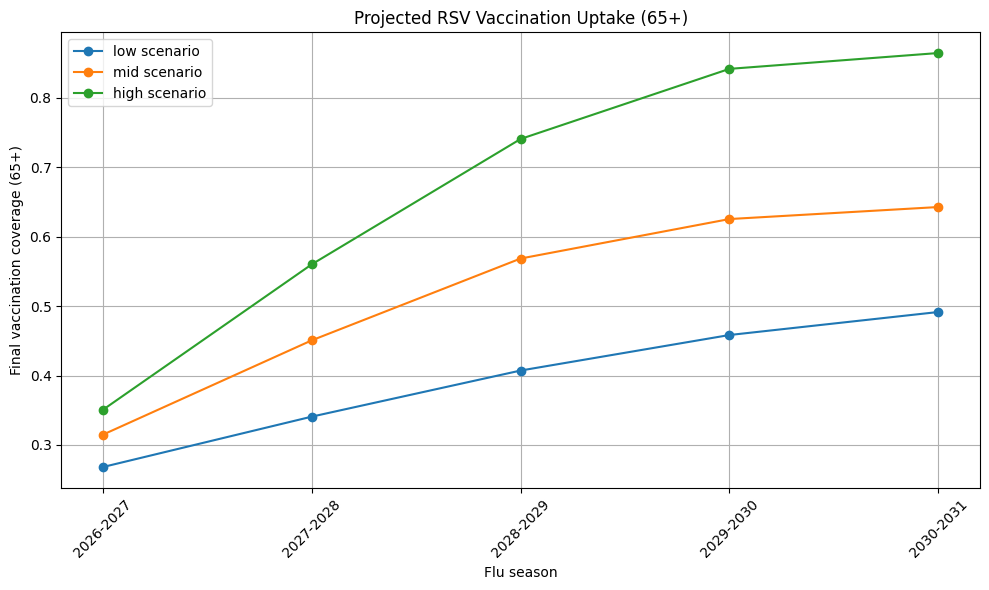

In [ ]:
# -----------------------------------------------------
# PLOT
# -----------------------------------------------------


plt.figure(figsize=(10,6))

for scen in future_all["scenario"].unique():
    
    df_plot = (
        future_all[future_all["scenario"] == scen]
        .groupby("flu_season")["vax_cov"]
        .max()
        .reset_index()
    )
    
    plt.plot(
        df_plot["flu_season"],
        df_plot["vax_cov"],
        marker="o",
        label=f"{scen} scenario"
    )

plt.xlabel("Flu season")
plt.ylabel("Final vaccination coverage (65+)")
plt.title("Projected RSV Vaccination Uptake (65+)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "projected_rsv_uptake_by_season.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

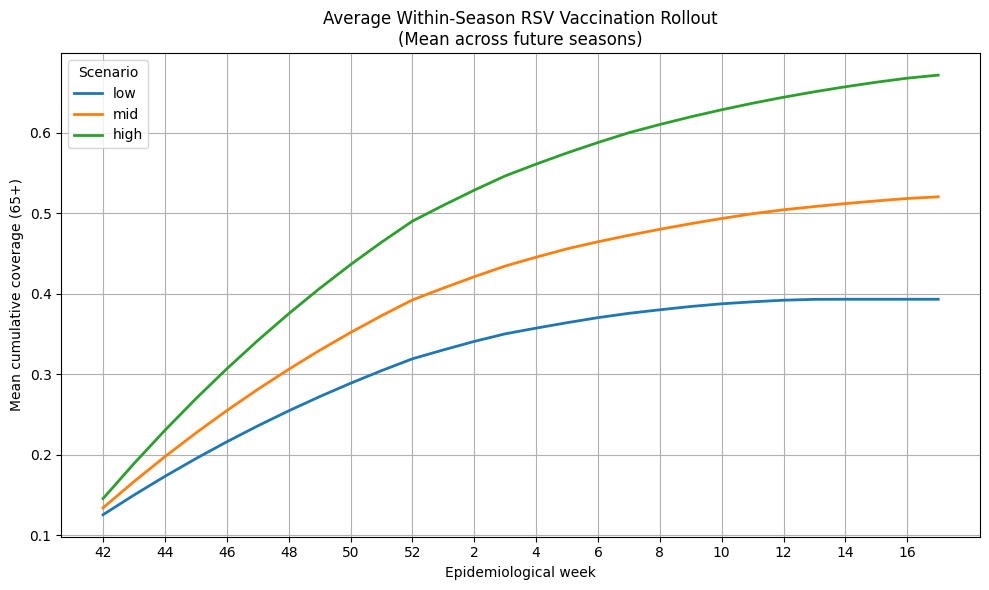

In [ ]:
plt.figure(figsize=(10,6))

for scen in future_all["scenario"].unique():
    
    df_plot = (
        future_all[future_all["scenario"] == scen]
        .groupby("season_week")["vax_cov"]
        .mean()
        .reset_index()
    )
    
    plt.plot(
        df_plot["season_week"],
        df_plot["vax_cov"],
        linewidth=2,
        label=scen
    )

weeks_real = list(range(42, 53)) + list(range(1, 18))

season_index = np.arange(3, 3 + len(weeks_real))  

plt.xticks(
    ticks=season_index[::2],   
    labels=weeks_real[::2]
)

plt.xlabel("Epidemiological week")
plt.ylabel("Mean cumulative coverage (65+)")
plt.title("Average Within-Season RSV Vaccination Rollout\n(Mean across future seasons)")
plt.grid(True)
plt.legend(title="Scenario")
plt.tight_layout()

plt.savefig(
    OUTPUT_PATH / "within_season_rsv_rollout_mean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()